
# Layer 1 — Dynamic Factor Model Backbone

This notebook implements **Layer 1** of the project:

> **Real-Time GDP Growth Nowcasting using a Hybrid Dynamic Factor Model with Machine Learning Residual Correction**

Scope in this notebook:

- audit the **actual local repository** before modeling;
- preserve the repository’s **first-day-of-month / first-day-of-quarter** timestamp semantics;
- construct a **vintage-aware GDP target history** and separate **truth tables**;
- ingest and transform the **monthly FRED-MD vintage files**;
- align monthly predictors with quarterly GDP in a **mixed-frequency state-space DFM**;
- estimate the DFM via **EM + Kalman filter / smoother**;
- produce **GDP nowcasts**, **news decomposition**, **coverage diagnostics**, and **Layer 2 artifacts**.

This notebook is aligned to **Section 3** of the methodological outline and the final project write-up, and uses the stable-subset block/tcode design from the uploaded data dictionary. The Layer 2 residual-correction model is **not** estimated here; the notebook exports the objects it will need.



## Non-negotiable date rule

The repository does **not** use artificial month-end timestamps as its native convention.

This notebook therefore:

- treats strings such as `2026-01-01` as **January 2026**, not as a month-end date;
- treats quarter markers using **period semantics** and sequence-aware parsing;
- avoids invalid synthetic dates such as `2026-02-29`;
- only converts to timestamp form when a downstream library requires it, and then uses the **period start timestamp** rather than a fabricated month-end.

Internally, audit and alignment logic use `pandas.Period` objects wherever possible.


In [1]:
from __future__ import annotations

import importlib
import json
import math
import hashlib
import platform
import sys
import warnings
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

try:
    import dfm_layer1_utils as _layer1_utils
    _layer1_utils = importlib.reload(_layer1_utils)

    from dfm_layer1_utils import (
        ProtocolConfig,
        apply_tcodes_to_snapshot,
        as_model_index,
        build_factor_mapping,
        build_quarterly_target_series_for_vintage,
        build_repo_catalog,
        build_target_and_truth_objects,
        choose_canonical_md_manifest,
        choose_canonical_qd_manifest,
        choose_vintage_schedule,
        completion_checklist_frame,
        compute_block_coverage,
        extract_nowcast_from_results,
        fit_dfm_single_vintage,
        get_quarter_end_month,
        infer_period_frequency_from_values,
        inspect_csv_schema,
        inspect_excel_workbook,
        load_fred_snapshot,
        locate_repo_root,
        make_diagnostics_row,
        oriented_factor_states,
        parse_periodish,
        protocol_summary_frame,
        run_layer1_dfm,
        select_monthly_panel,
        select_target_workbooks,
        serialize_protocol,
        stable_subset_metadata,
        summarize_manifest,
        within_quarter_origin,
        quarter_of_vintage,
    )
except ImportError as exc:
    raise ImportError(
        "dfm_layer1_utils.py was not found next to the notebook. "
        "Place the helper file in the repository root (or the notebook working directory) and rerun."
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:

import statsmodels
import openpyxl

env = pd.DataFrame(
    [
        {"component": "python", "version": platform.python_version()},
        {"component": "pandas", "version": pd.__version__},
        {"component": "numpy", "version": np.__version__},
        {"component": "statsmodels", "version": statsmodels.__version__},
        {"component": "openpyxl", "version": openpyxl.__version__},
    ]
)
display(env)


,component,version
0,python,3.13.5
1,pandas,2.3.3
2,numpy,2.1.3
3,statsmodels,0.14.6
4,openpyxl,3.1.5


## 1. Project setup

In [3]:

# If the notebook is placed inside the repository (recommended), auto-detection should work.
# Otherwise, set REPO_ROOT_HINT to the absolute local path of the cloned repository.
REPO_ROOT_HINT = None

REPO_ROOT = Path(REPO_ROOT_HINT) if REPO_ROOT_HINT else locate_repo_root(Path.cwd())
if REPO_ROOT is None or not REPO_ROOT.exists():
    raise FileNotFoundError(
        "Could not locate the Nowcasting-GDP-Growth repository automatically. "
        "Set REPO_ROOT_HINT to the local repository path and rerun."
    )

RAW_DIR = REPO_ROOT / "data" / "raw"
OUTPUT_DIR = REPO_ROOT / "outputs" / "layer1_dfm"

print("Repository root:", REPO_ROOT)
print("Raw data directory:", RAW_DIR)
print("Output directory:", OUTPUT_DIR)


Repository root: /Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/Time Series/Final Project/Test/hybrid_dfm_ml_nowcasting
Raw data directory: /Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/Time Series/Final Project/Test/hybrid_dfm_ml_nowcasting/data/raw
Output directory: /Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/Time Series/Final Project/Test/hybrid_dfm_ml_nowcasting/outputs/layer1_dfm


## 2. Repository audit and file mapping

In [4]:

catalog = build_repo_catalog(REPO_ROOT)

catalog_summary = (
    catalog.groupby("group", dropna=False)
    .agg(
        n_files=("path", "size"),
        first_vintage=("vintage_period", "min"),
        last_vintage=("vintage_period", "max"),
        total_size_mb=("size_mb", "sum"),
    )
    .reset_index()
    .sort_values(["group"])
)

md_manifest = choose_canonical_md_manifest(catalog)
qd_manifest = choose_canonical_qd_manifest(catalog)
target_workbooks = select_target_workbooks(REPO_ROOT)

manifest_summary = pd.concat(
    [
        summarize_manifest(md_manifest, "Canonical monthly predictor manifest"),
        summarize_manifest(qd_manifest, "Canonical quarterly predictor manifest"),
    ],
    ignore_index=True,
)

workbook_map = pd.DataFrame(
    [
        {"object_name": k, "path": str(v.relative_to(REPO_ROOT))}
        for k, v in sorted(target_workbooks.items())
    ]
)

display(catalog_summary)
display(manifest_summary)
display(workbook_map)


,group,n_files,first_vintage,last_vintage,total_size_mb
0,excel_workbook,6,NaT,NaT,1.581030
1,fred_md_current,15,2025-01,2026-02,9.417383
2,fred_md_hist_2015_2024,120,2015-01,2024-02,69.586911
3,fred_md_hist_legacy,187,1999-08,2014-12,213.703775
4,fred_qd_current,15,2025-01,2026-02,7.323709
5,fred_qd_hist_2018_2024,80,2018-05,2024-12,36.600430
6,other,513,NaT,NaT,127.753791
7,sample_csv,2,2016-06,2016-07,0.112094


,label,count,min_vintage,max_vintage,min_path,max_path
0,Canonical monthly predictor manifest,309,1999-08,2026-02,data/raw/Historical FRED-MD Vintages Final/1999-08.csv,data/raw/FRED-MD-MONTHLY/2026-02-MD.csv
1,Canonical quarterly predictor manifest,91,2018-05,2026-02,data/raw/Historical vintages of FRED-QD 2018-05 to 2024-12/FRED-QD_2018m05.csv,data/raw/FRED-QD-QUARTERLY/2026-02-QD.csv


,object_name,path
0,GDPplus_Vintages.xlsx,data/raw/GDPplus_Vintages.xlsx
1,ROUTPUTQvQd.xlsx,data/raw/ROUTPUTQvQd.xlsx
2,meanGrowth.xlsx,data/raw/meanGrowth.xlsx
3,medianGrowth.xlsx,data/raw/medianGrowth.xlsx
4,routputMvQd.xlsx,data/raw/routputMvQd.xlsx
5,routput_first_second_third.xlsx,data/raw/routput_first_second_third.xlsx


In [5]:

def hash_file(path: Path) -> str:
    return hashlib.md5(path.read_bytes()).hexdigest()

hash_checks = []

md_current = REPO_ROOT / "data" / "raw" / "FRED-MD-MONTHLY" / "current.csv"
if md_current.exists() and not md_manifest.empty:
    latest_md = REPO_ROOT / md_manifest.iloc[-1]["path"]
    hash_checks.append(
        {
            "file_group": "monthly current vs latest dated file",
            "current_path": str(md_current.relative_to(REPO_ROOT)),
            "latest_dated_path": str(latest_md.relative_to(REPO_ROOT)),
            "same_bytes": hash_file(md_current) == hash_file(latest_md),
        }
    )

qd_current = REPO_ROOT / "data" / "raw" / "FRED-QD-QUARTERLY" / "current.csv"
if qd_current.exists() and not qd_manifest.empty:
    latest_qd = REPO_ROOT / qd_manifest.iloc[-1]["path"]
    hash_checks.append(
        {
            "file_group": "quarterly current vs latest dated file",
            "current_path": str(qd_current.relative_to(REPO_ROOT)),
            "latest_dated_path": str(latest_qd.relative_to(REPO_ROOT)),
            "same_bytes": hash_file(qd_current) == hash_file(latest_qd),
        }
    )

display(pd.DataFrame(hash_checks))


,file_group,current_path,latest_dated_path,same_bytes
0,monthly current vs latest dated file,data/raw/FRED-MD-MONTHLY/current.csv,data/raw/FRED-MD-MONTHLY/2026-02-MD.csv,True
1,quarterly current vs latest dated file,data/raw/FRED-QD-QUARTERLY/current.csv,data/raw/FRED-QD-QUARTERLY/2026-02-QD.csv,True


## 3. Raw file inspection and schema understanding

In [6]:

def compact_csv_inspection(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    info = inspect_csv_schema(path)
    summary = pd.DataFrame(
        [
            {
                "path": str(Path(info["path"]).relative_to(REPO_ROOT)),
                "date_col": info["date_col"],
                "inferred_freq": info["inferred_freq"],
                "metadata_row_count": info["metadata_row_count"],
                "has_tcode_row": info["has_tcode_row"],
                "n_rows": info["n_rows"],
                "n_cols": info["n_cols"],
                "min_timestamp": info["min_timestamp"],
                "max_timestamp": info["max_timestamp"],
            }
        ]
    )
    return summary, info["preview"]

representative_paths = []
if len(md_manifest) > 0:
    representative_paths.extend(
        [
            REPO_ROOT / md_manifest.iloc[0]["path"],
            REPO_ROOT / md_manifest.iloc[len(md_manifest) // 2]["path"],
            REPO_ROOT / md_manifest.iloc[-1]["path"],
        ]
    )
if len(qd_manifest) > 0:
    representative_paths.extend(
        [
            REPO_ROOT / qd_manifest.iloc[0]["path"],
            REPO_ROOT / qd_manifest.iloc[-1]["path"],
        ]
    )

sample_dir = REPO_ROOT / "data" / "sample"
if sample_dir.exists():
    sample_csvs = sorted(sample_dir.glob("*.csv"))
    if sample_csvs:
        representative_paths.append(sample_csvs[0])

for path in representative_paths:
    print(f"\nInspecting: {path.relative_to(REPO_ROOT)}")
    summary, preview = compact_csv_inspection(path)
    display(summary)
    display(preview)



Inspecting: data/raw/Historical FRED-MD Vintages Final/1999-08.csv


,path,date_col,inferred_freq,metadata_row_count,has_tcode_row,n_rows,n_cols,min_timestamp,max_timestamp
0,data/raw/Historical FRED-MD Vintages Final/1999-08.csv,sasdate,M,1,True,488,113,1959-01-01,1999-07-01


,sasdate,RPI,W875RX1,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPMAT,IPMANSICS,CUMFNS,CLF16OV,CE16OV,UNRATE,UEMPMEAN,UEMPLT5,UEMP5TO14,UEMP15OV,UEMP15T26,UEMP27OV,CLAIMSx,PAYEMS,USGOOD,CES1021000001,USCONS,MANEMP,DMANEMP,NDMANEMP,SRVPRD,USWTRADE,USTRADE,USFIRE,USGOVT,CES0600000007,AWOTMAN,AWHMAN,HOUST,HOUSTNE,HOUSTMW,HOUSTS,HOUSTW,PERMIT,PERMITNE,PERMITMW,PERMITS,PERMITW,AMDMNOx,ANDENOx,AMDMUOx,BUSINVx,ISRATIOx,M1SL,M2SL,M2REAL,AMBSL,TOTRESNS,NONBORRES,BUSLOANS,REALLN,NONREVSL,CONSPI,S&P 500,S&P: indust,S&P div yield,S&P PE ratio,FEDFUNDS,CP3Mx,TB3MS,TB6MS,GS1,GS5,GS10,AAA,BAA,COMPAPFFx,TB3SMFFM,TB6SMFFM,T1YFFM,T5YFFM,T10YFFM,AAAFFM,BAAFFM,TWEXMMTH,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPIFGS,PPIFCG,PPIITM,PPICRM,OILPRICEx,PPICMM,CPIAUCSL,CPIAPPSL,CPITRNSL,CPIMEDSL,CUSR0000SAC,CUSR0000SAD,CUSR0000SAS,CPIULFSL,CUSR0000SA0L2,CUSR0000SA0L5,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,MZMSL,DTCOLNVHFNM,DTCTHFNM,INVEST,VXOCLSx
0,Transform:,5.0,5.0,5.0,5.0,5.000,5.000,5.000,5.000,5.000,5.000,2.0,5.0,5.0,2.0,2.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,1.0,2.0,1.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0,2.00,6.0,6.0,5.0,6.0,6.000,7.0,6.0,6.0,6.0,2.000000,5.00,5.00,2.000000,5.000000,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,5.0,5.0000,5.0000,5.0000,5.0000,6.0,6.0,6.0,6.0,6.00,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.00,6.00,6.00,2.0,6.0,6.0,6.0,6.0,1.0
1,01/01/1959,1691.3,1575.1,198740.0,17583.0,34.431,33.836,33.225,37.314,35.084,32.264,80.2,67936.0,63868.0,6.0,16.3,1574.0,1169.0,1396.0,594.0,802.0,292.0,52408.0,20060.0,752.0,2957.0,16351.0,9108.0,7243.0,32348.0,3037.0,7887.0,2511.0,7974.0,39.6,2.5,40.1,1657.0,350.0,452.0,505.0,350.0,NaN,NaN,NaN,NaN,NaN,15647.0,NaN,44685.0,87140.0,1.51,138.9,286.6,988.3,38.5,18.889,18338.0,NaN,NaN,49.0,0.127971,55.62,59.30,3.158342,18.445741,2.48,3.30,2.82,3.09,3.36,4.01,4.02,4.12,4.87,0.82,0.34,0.61,0.88,1.53,1.54,1.64,2.39,NaN,4.3122,359.8417,2.8065,0.9671,33.1,33.4,30.6,31.6,3.00,32.5,29.0,44.8,29.3,21.1,33.3,38.1,22.9,28.9,30.7,29.6,2.28,2.87,2.16,NaN,274.9,6476.0,12298.0,NaN,NaN
2,02/01/1959,1699.2,1581.7,201548.0,17712.0,35.105,34.293,33.513,37.588,36.195,32.857,81.4,67649.0,63684.0,5.9,15.5,1554.0,1164.0,1277.0,545.0,732.0,284.0,52568.0,20121.0,743.0,2935.0,16443.0,9189.0,7254.0,32447.0,3042.0,7932.0,2513.0,7984.0,39.6,2.6,40.2,1667.0,346.0,469.0,508.0,344.0,NaN,NaN,NaN,NaN,NaN,16374.0,NaN,45793.0,87440.0,1.49,139.4,287.7,992.1,38.8,18.570,18065.0,NaN,NaN,49.5,0.128505,54.77,58.33,3.219518,18.418119,2.43,3.26,2.70,3.13,3.54,3.96,3.96,4.14,4.89,0.83,0.27,0.70,1.11,1.53,1.53,1.71,2.46,NaN,4.3133,359.8417,2.8093,0.9748,33.2,33.4,30.7,31.4,3.00,32.5,29.0,44.7,29.4,21.2,33.3,38.1,23.0,28.9,30.7,29.6,2.29,2.88,2.17,NaN,276.0,6476.0,12298.0,NaN,NaN
3,03/01/1959,1712.8,1595.6,204077.0,17860.0,35.611,34.500,33.677,37.588,37.135,33.371,82.5,68068.0,64267.0,5.6,15.3,1459.0,1093.0,1210.0,530.0,680.0,258.0,52883.0,20313.0,743.0,2958.0,16612.0,9329.0,7283.0,32570.0,3051.0,7980.0,2523.0,8002.0,39.9,2.8,40.4,1620.0,330.0,413.0,503.0,374.0,NaN,NaN,NaN,NaN,NaN,16741.0,NaN,46951.0,87890.0,1.48,139.7,289.2,997.2,38.8,18.431,17832.0,NaN,NaN,50.0,0.128766,56.16,59.79,3.151709,18.999351,2.80,3.35,2.80,3.13,3.61,3.99,3.99,4.13,4.85,0.55,0.00,0.33,0.81,1.19,1.19,1.33,2.05,NaN,4.3228,359.8417,2.8127,0.9698,33.2,33.3,30.7,31.5,2.97,32.9,29.0,44.7,29.6,21.3,33.2,38.3,23.0,28.9,30.7,29.6,2.31,2.87,2.19,NaN,277.4,6508.0,12349.0,NaN,NaN
4,04/01/1959,1723.0,1606.0,206542.0,17871.0,36.370,34.999,34.171,38.181,38.161,34.083,84.0,68339.0,64768.0,5.2,14.9,1494.0,934.0,1039.0,408.0,631.0,244.0,53132.0,20514.0,743.0,3038.0,16733.0,9439.0,7294.0,32618.0,3064.0,7937.0,2534.0,8016.0,40.0,2.8,40.5,1590.0,275.0,391.0,536.0,388.0,NaN,NaN,NaN,NaN,NaN,16926.0,NaN,47728.0,89070.0,1.48,139.7,290.1,1000.3,38.9,18.678,17986.0,NaN,NaN,50.5,0.129057,57.10,60.92,3.111506,19.272973,2.96,3.42,2.95,3.27,3.72,4.12,4.12,4.23,4.86,0.46,-0.01,0.31,0.76,


Inspecting: data/raw/Historical FRED-MD Vintages Final/2012-06.csv


,path,date_col,inferred_freq,metadata_row_count,has_tcode_row,n_rows,n_cols,min_timestamp,max_timestamp
0,data/raw/Historical FRED-MD Vintages Final/2012-06.csv,sasdate,M,1,True,642,127,1959-01-01,2012-05-01


...

,path,date_col,inferred_freq,metadata_row_count,has_tcode_row,n_rows,n_cols,min_timestamp,max_timestamp
0,data/raw/FRED-QD-QUARTERLY/2026-02-QD.csv,sasdate,Q,2,True,270,246,1959-01-01,2025-10-01


,sasdate,GDPC1,PCECC96,PCDGx,PCESVx,PCNDx,GPDIC1,FPIx,Y033RC1Q027SBEAx,PNFIx,PRFIx,A014RE1Q156NBEA,GCEC1,A823RL1Q225SBEA,FGRECPTx,SLCEx,EXPGSC1,IMPGSC1,DPIC96,OUTNFB,OUTBS,OUTMS,INDPRO,IPFINAL,IPCONGD,IPMAT,IPDMAT,IPNMAT,IPDCONGD,IPB51110SQ,IPNCONGD,IPBUSEQ,IPB51220SQ,TCU,CUMFNS,PAYEMS,USPRIV,MANEMP,SRVPRD,USGOOD,DMANEMP,NDMANEMP,USCONS,USEHS,USFIRE,USINFO,USPBS,USLAH,USSERV,USMINE,USTPU,USGOVT,USTRADE,USWTRADE,CES9091000001,CES9092000001,CES9093000001,CE16OV,CIVPART,UNRATE,UNRATESTx,UNRATELTx,LNS14000012,LNS14000025,LNS14000026,UEMPLT5,UEMP5TO14,UEMP15T26,UEMP27OV,LNS13023621,LNS13023557,LNS13023705,LNS13023569,LNS12032194,HOABS,HOAMS,HOANBS,AWHMAN,AWHNONAG,AWOTMAN,HWIx,HOUST,HOUST5F,PERMIT,HOUSTMW,HOUSTNE,HOUSTS,HOUSTW,CMRMTSPLx,RSAFSx,AMDMNOx,ACOGNOx,AMDMUOx,ANDENOx,INVCQRMTSPL,PCECTPI,PCEPILFE,GDPCTPI,GPDICTPI,IPDBS,...,TB6MS,GS1,GS10,MORTGAGE30US,AAA,BAA,BAA10YM,MORTG10YRx,TB6M3Mx,GS1TB3Mx,GS10TB3Mx,CPF3MTB3Mx,BOGMBASEREALx,M1REAL,M2REAL,BUSLOANSx,CONSUMERx,NONREVSLx,REALLNx,REVOLSLx,TOTALSLx,DRIWCIL,TABSHNOx,TLBSHNOx,LIABPIx,TNWBSHNOx,NWPIx,TARESAx,HNOREMQ027Sx,TFAABSHNOx,VIXCLSx,USSTHPI,SPCS10RSA,SPCS20RSA,TWEXAFEGSMTHx,EXUSEU,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,UMCSENTx,USEPUINDXM,B020RE1Q156NBEA,B021RE1Q156NBEA,GFDEGDQ188S,GFDEBTNx,IPMANSICS,IPB51222S,IPFUELS,UEMPMEAN,CES0600000007,TOTRESNS,NONBORRES,GS5,TB3SMFFM,T5YFFM,AAAFFM,WPSID62,PPICMM,CPIAPPSL,CPITRNSL,CPIMEDSL,CUSR0000SAC,CUSR0000SAD,CUSR0000SAS,CPIULFSL,CUSR0000SA0L2,CUSR0000SA0L5,CES0600000008,DTCOLNVHFNM,DTCTHFNM,INVEST,HWIURATIOx,CLAIMSx,BUSINVx,ISRATIOx,CONSPIx,CP3M,COMPAPFF,PERMITNE,PERMITMW,PERMITS,PERMITW,NIKKEI225,NASDAQCOM,CUSR0000SEHC,TLBSNNCBx,TLBSNNCBBDIx,TTAABSNNCBx,TNWMVBSNNCBx,TNWMVBSNNCBBDIx,TLBSNNBx,TLBSNNBBDIx,TABSNNBx,TNWBSNNBx,TNWBSNNBBDIx,CNCFx,S&P 500,S&P div yield,S&P PE ratio
0,factors,0.000,0.000,1.0000,1.0000,1.0000,0.000,0.0000,1.0000,1.0000,1.0000,1.0,0.000,1.0,1.0000,1.0000,1.000,1.000,0.000,0.000,0.000,0.0,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.000000,0.000000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0,1.0,1.0,1.0,1.0000,0.000,0.0,0.000,1.0000,1.0,1.0000,0,0.0000,0.0000,1.0,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0,1.0000,1.0,1.0,0.000,0.0000,0.000,1.000,1.000,...,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,1.0000,1.0,1.00,1.00,1.00,1.00,0.000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0,0.0000,1.0,0.00,1.000,0.00000,1.00,0.0000,1.00,1.00,1.00,1.0,1.0,1.0,1.0,1.0,1.0,1.0000,1.0000,1.0000,1.0000,1.0,1.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.00,0.00,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.00,0.0000,0.00,0.00,0.00,0.0,0.0,0.000000e+00,0.00,0.00,0.0000,1.0000,0.0000,0.0000
1,transform,5.000,5.000,5.0000,5.0000,5.0000,5.000,5.0000,5.0000,5.0000,5.0000,1.0,5.000,1.0,5.0000,5.0000,5.000,5.000,5.000,5.000,5.000,5.0,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,1.0,1.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,2.0000,2.0000,2.000000,2.000000,2.0000,2.0000,2.0000,5.0000,5.0000,5.0000,5.0000,5.0,5.0,5.0,5.0,5.0000,5.000,5.0,5.000,1.0000,2.0,2.0000,1,5.0000,5.0000,5.0,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0,5.0000,5.0,5.0,6.000,6.0000,6.000,6.000,6.000,...,2.0000,2.0000,2.0000,2.0,2.0000,2.0000,1.0000,1.0,1.00,1.00,1.00,1.00,5.000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0,5.0000,1.0,5.00,5.000,5.00000,5.00,1.0000,5.00,5.00,5.00,1.0,5.0,5.0,5.0,5.0,5.0,5.0000,5.0000,5.0000,5.0000,1.0,2.0,2.0,2.0,2.0,2.0,5.0000,5.0000,5.0000,2.0000,2.0000,6.0000,7.0000,2.0000,1


Inspecting: data/sample/2016-06-29.csv


,path,date_col,inferred_freq,metadata_row_count,has_tcode_row,n_rows,n_cols,min_timestamp,max_timestamp
0,data/sample/2016-06-29.csv,Date,M,0,False,378,30,1985-01-01,2016-06-01


,Date,PAYEMS,JTSJOL,CPIAUCSL,DGORDER,HSN1F,RSAFS,UNRATE,HOUST,INDPRO,PPIFIS,DSPIC96,BOPTEXP,BOPTIMP,WHLSLRIMSA,TTLCONS,IR,CPILFESL,PCEPILFE,PCEPI,PERMIT,TCU,BUSINV,IQ,GACDISA066MSFRBNY,PCEC96,GACDFSA066MSFRBPHI,GDPC1,ULCNFB,A261RX1Q020SBEA
0,1/1/85,96373.0,NaN,105.7,NaN,645.0,NaN,7.3,1711.0,56.6447,NaN,5433.6,NaN,NaN,NaN,NaN,NaN,107.1,55.854,55.732,1660.0,79.9,NaN,NaN,NaN,NaN,5.5,NaN,NaN,NaN
1,2/1/85,96497.0,NaN,106.3,NaN,682.0,NaN,7.2,1632.0,56.8492,NaN,5384.1,NaN,NaN,NaN,NaN,NaN,107.7,56.153,55.998,1662.0,80.0,NaN,NaN,NaN,NaN,10.9,NaN,NaN,NaN
2,3/1/85,96843.0,NaN,106.8,NaN,671.0,NaN,7.2,1800.0,56.9349,NaN,5358.6,NaN,NaN,NaN,NaN,75.5,108.1,56.358,56.224,1727.0,79.9,NaN,84.0,NaN,NaN,31.0,7469.5,65.636,7407.5
3,4/1/85,97039.0,NaN,107.0,NaN,620.0,NaN,7.3,1821.0,56.7821,NaN,5450.3,NaN,NaN,NaN,NaN,NaN,108.4,56.431,56.310,1664.0,79.5,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN
4,5/1/85,97313.0,NaN,107.2,NaN,678.0,NaN,7.2,1680.0,56.8643,NaN,5578.0,NaN,NaN,NaN,NaN,NaN,108.8,56.633,56.450,1709.0,79.4,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN
5,6/1/85,97459.0,NaN,107.5,NaN,722.0,NaN,7.4,1676.0,56.9021,NaN,5459.2,NaN,NaN,NaN,NaN,75.8,109.1,56.827,56.609,1716.0,79.3,NaN,84.4,NaN,NaN,-2.4,7537.9,66.033,7461.5


In [7]:

for workbook_name, workbook_path in sorted(target_workbooks.items()):
    print(f"\nWorkbook audit: {workbook_name}")
    display(inspect_excel_workbook(workbook_path))



Workbook audit: GDPplus_Vintages.xlsx


,sheet_name,max_row,max_col,preview_top_left
0,Sheet1,265,150,"[[Date, GDPPLUS_082913, GDPPLUS_092613, GDPPLUS_110713, GDPPLUS_120513, GDPPLUS_122013, GDPPLUS_013014, GDPPLUS_0228..."



Workbook audit: ROUTPUTQvQd.xlsx


,sheet_name,max_row,max_col,preview_top_left
0,ROUTPUT,317,243,"[[DATE, ROUTPUT65Q4, ROUTPUT66Q1, ROUTPUT66Q2, ROUTPUT66Q3, ROUTPUT66Q4, ROUTPUT67Q1, ROUTPUT67Q2], [1947:Q1, 306.4,..."



Workbook audit: meanGrowth.xlsx


...

,sheet_name,max_row,max_col,preview_top_left
0,NGDP,231,7,"[[YEAR, QUARTER, dngdp2, dngdp3, dngdp4, dngdp5, dngdp6, None], [1968.0, 4.0, 6.5861, 5.0652, 5.9311, 7.2288, 6.646,..."
1,PGDP,231,7,"[[YEAR, QUARTER, dpgdp2, dpgdp3, dpgdp4, dpgdp5, dpgdp6, None], [1968.0, 4.0, 3.3192, 3.2919, 3.265, 3.2386, 3.2126,..."
2,CPROF,231,7,"[[YEAR, QUARTER, dcprof2, dcprof3, dcprof4, dcprof5, dcprof6, None], [1968.0, 4.0, 1.5779, -1.5534, 0.0, 8.0768, 7.9..."
3,EMP_AVG,231,7,"[[YEAR, QUARTER, dempa2, dempa3, dempa4, dempa5, dempa6, None], [1968.0, 4.0, #N/A, #N/A, #N/A, #N/A, #N/A, None], [..."
4,EMP_PCG,231,7,"[[YEAR, QUARTER, dempb2, dempb3, dempb4, dempb5, dempb6, None], [1968.0, 4.0, #N/A, #N/A, #N/A, #N/A, #N/A, None], [..."
5,INDPROD,231,7,"[[YEAR, QUARTER, dindprod2, dindprod3, dindprod4, dindprod5, dindprod6, None], [1968.0, 4.0, 2.4464, 0.0, 0.0, 4.907..."
6,HOUSING,231,7,"[[YEAR, QUARTER, dhousing2, dhousing3, dhousing4, dhousing5, dhousing6, None], [1968.0, 4.0, 0.0, 8.1316, 13.5411, 1..."
7,RGDP,231,7,"[[YEAR, QUARTER, drgdp2, drgdp3, drgdp4, drgdp5, drgdp6, None], [1968.0, 4.0, 2.6103, 1.7096, 2.2358, 4.3318, 4.037,..."
8,RCONSUM,231,7,"[[YEAR, QUARTER, drconsum2, drconsum3, drconsum4, drconsum5, drconsum6, None], [1968.0, 4.0, #N/A, #N/A, #N/A, #N/A,..."
9,RNRESIN,231,7,"[[YEAR, QUARTER, drnresin2, drnresin3, drnresin4, drnresin5, drnresin6, None], [1968.0, 4.0, #N/A, #N/A, #N/A, #N/A,..."



Workbook audit: routputMvQd.xlsx


,sheet_name,max_row,max_col,preview_top_left
0,routput,317,726,"[[DATE, ROUTPUT65M11, ROUTPUT65M12, ROUTPUT66M1, ROUTPUT66M2, ROUTPUT66M3, ROUTPUT66M4, ROUTPUT66M5], [1947:Q1, 306...."



Workbook audit: routput_first_second_third.xlsx


,sheet_name,max_row,max_col,preview_top_left
0,NOTES,11,1,"[[Real GNP/GDP, None, None, None, None, None, None, None], [Variable ID: ROUTPUT, None, None, None, None, None, None..."
1,DATA,246,5,"[[Real GNP/GDP (ROUTPUT), None, None, None, None, None, None, None], [Q/Q Growth (Annual Rate, Percentage Points), N..."


## 4. Protocol locking and configuration


The protocol is locked **before** estimation:

- benchmark window starts at **2000Q1**;
- primary truth is **third-release GDP growth**;
- robustness truths are **latest RTDSM** and **GDPplus**;
- the main Layer 1 predictor flow is **monthly FRED-MD vintages**;
- the default shipped model uses the **stable subset** because the uploaded data dictionary provides an explicit ex ante block/tcode/anchor map for it;
- the DFM uses **1 global factor + 1 factor per block** and a low-order factor VAR;
- ragged edges stay **inside** the state-space system;
- Layer 2 is fed only with **vintage-legal** DFM outputs.


In [8]:

RUN_MODE = "research"   # set to "debug" for a short smoke test; for a fast late-sample news() check, temporarily start at 2025Q4 with vintage_limit=5

if RUN_MODE == "debug":
    config = ProtocolConfig(
        repo_root=str(REPO_ROOT),
        output_dir=str(OUTPUT_DIR),
        benchmark_start_quarter="2000Q1",
        panel_mode="stable",
        truth_main="third_release",
        truth_robustness=("latest_rtdsm", "gdpplus"),
        candidate_factor_orders=(1, 2),
        fixed_factor_order=1,
        select_factor_order_per_vintage=False,
        idiosyncratic_ar1=True,
        em_maxiter=25,
        em_tolerance=1e-5,
        vintage_limit=6,
        min_monthly_obs=24,
        force_refit=True,
    )
else:
    config = ProtocolConfig(
        repo_root=str(REPO_ROOT),
        output_dir=str(OUTPUT_DIR),
        benchmark_start_quarter="2000Q1",
        panel_mode="stable",
        truth_main="third_release",
        truth_robustness=("latest_rtdsm", "gdpplus"),
        candidate_factor_orders=(1, 2),
        fixed_factor_order=1,
        select_factor_order_per_vintage=False,
        idiosyncratic_ar1=True,
        em_maxiter=100,
        em_tolerance=1e-6,
        vintage_limit=None,
        min_monthly_obs=24,
        force_refit=True,
    )

display(protocol_summary_frame(config))
serialize_protocol(config, OUTPUT_DIR / "layer1_protocol.json")


,setting,value
0,repo_root,/Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/Time Series/Final Project/Test/hybrid_dfm_ml_nowc...
1,output_dir,/Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/Time Series/Final Project/Test/hybrid_dfm_ml_nowc...
2,benchmark_start_quarter,2000Q1
3,panel_mode,stable
4,truth_main,third_release
5,truth_robustness,"(latest_rtdsm, gdpplus)"
6,candidate_factor_orders,"(1, 2)"
7,fixed_factor_order,1
8,select_factor_order_per_vintage,False
9,idiosyncratic_ar1,True


## 5. Date convention audit and parsing rules


The local repository audit should verify the date semantics **from the files themselves** rather than from assumptions.

Observed conventions that this notebook is designed to support:

- **monthly FRED-MD snapshots** use a first-of-month date column (for example `1/1/1959`, `2/1/1959`, ...), typically with a leading `Transform:` row;
- **quarterly FRED-QD snapshots** use a quarter marker sequence such as `3/1/1959`, `6/1/1959`, ... together with leading `factors` and `transform` metadata rows;
- workbook-based target files may use quarter labels, quarter-start markers, or a vintage-by-observation matrix layout, so the notebook inspects them locally at runtime.

The parser therefore infers frequency from the **sequence** and metadata rows, not from a blind month-end conversion.


In [9]:

def preview_date_parsing(path: Path, n: int = 8) -> pd.DataFrame:
    raw = pd.read_csv(path, usecols=[0], nrows=max(12, n))
    info = inspect_csv_schema(path)
    date_col = info["date_col"]
    skip = int(info["metadata_row_count"])
    raw_values = raw[date_col].iloc[skip: skip + n].astype(str).tolist()
    freq = info["inferred_freq"]
    periods = [parse_periodish(x, freq_hint=freq) for x in raw_values]
    timestamps = [p.to_timestamp() if (p is not None and not pd.isna(p)) else pd.NaT for p in periods]
    return pd.DataFrame(
        {
            "raw_date_string": raw_values,
            "inferred_freq": [freq] * len(raw_values),
            "parsed_period": [str(p) if p is not None and not pd.isna(p) else None for p in periods],
            "period_start_timestamp": timestamps,
        }
    )

latest_md_path = REPO_ROOT / md_manifest.iloc[-1]["path"]
display(preview_date_parsing(latest_md_path))

if len(qd_manifest) > 0:
    latest_qd_path = REPO_ROOT / qd_manifest.iloc[-1]["path"]
    display(preview_date_parsing(latest_qd_path))

assert inspect_csv_schema(latest_md_path)["max_timestamp"].day == 1, "Monthly repo timestamps should remain first-of-month markers."


,raw_date_string,inferred_freq,parsed_period,period_start_timestamp
0,1/1/1959,M,1959-01,1959-01-01
1,2/1/1959,M,1959-02,1959-02-01
2,3/1/1959,M,1959-03,1959-03-01
3,4/1/1959,M,1959-04,1959-04-01
4,5/1/1959,M,1959-05,1959-05-01
5,6/1/1959,M,1959-06,1959-06-01
6,7/1/1959,M,1959-07,1959-07-01
7,8/1/1959,M,1959-08,1959-08-01


,raw_date_string,inferred_freq,parsed_period,period_start_timestamp
0,3/1/1959,Q,1959Q1,1959-01-01
1,6/1/1959,Q,1959Q2,1959-04-01
2,9/1/1959,Q,1959Q3,1959-07-01
3,12/1/1959,Q,1959Q4,1959-10-01
4,3/1/1960,Q,1960Q1,1960-01-01
5,6/1/1960,Q,1960Q2,1960-04-01
6,9/1/1960,Q,1960Q3,1960-07-01
7,12/1/1960,Q,1960Q4,1960-10-01


## 6. Vintage-aware target construction

In [10]:

target_objects = build_target_and_truth_objects(REPO_ROOT)

target_summary_rows = []
for name, obj in target_objects.items():
    if isinstance(obj, pd.DataFrame):
        summary_row = {
            "object_name": name,
            "n_rows": len(obj),
            "columns": ", ".join(map(str, obj.columns.tolist()[:12])),
        }
        for candidate in ["vintage_period", "obs_period", "quarter"]:
            if candidate in obj.columns:
                summary_row[f"{candidate}_min"] = obj[candidate].min()
                summary_row[f"{candidate}_max"] = obj[candidate].max()
        target_summary_rows.append(summary_row)

target_summary = pd.DataFrame(target_summary_rows)
display(target_summary)

target_vintage_table = target_objects["target_vintage_table"]
display(target_vintage_table.head(10))

if "truth_release_table" in target_objects:
    display(target_objects["truth_release_table"].head(10))
if "truth_third_release" in target_objects:
    display(target_objects["truth_third_release"].head(10))
if "truth_latest" in target_objects:
    display(target_objects["truth_latest"].head(10))
if "truth_gdpplus" in target_objects:
    display(target_objects["truth_gdpplus"].head(10))


/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,object_name,n_rows,columns,vintage_period_min,vintage_period_max,obs_period_min,obs_period_max,quarter_min,quarter_max
0,target_vintage_table,229100,"vintage_period, obs_period, level, vintage_freq, obs_freq, vintage_timestamp_start, quarter_timestamp_start, gdp_gro...",1965-11,2026-03,1947Q1,2025Q4,NaT,NaT
1,truth_latest,315,"quarter, vintage_period, latest_rtdsm",2026-03,2026-03,NaT,NaT,1947Q2,2025Q4
2,truth_release_table,240,"quarter, first_release, second_release, third_release, latest",NaT,NaT,NaT,NaT,1965Q3,2025Q2
3,truth_third_release,240,"quarter, third_release",NaT,NaT,NaT,NaT,1965Q3,2025Q2
4,truth_gdpplus,264,"quarter, gdpplus, release_date, latest_release_period",NaT,NaT,NaT,NaT,1960Q1,2025Q4
5,spf_mean,230,"quarter, spf_mean, source_sheet, horizon_col",NaT,NaT,NaT,NaT,1968Q4,2026Q1
6,spf_median,230,"quarter, spf_median, source_sheet, horizon_col",NaT,NaT,NaT,NaT,1968Q4,2026Q1


,vintage_period,obs_period,level,vintage_freq,obs_freq,vintage_timestamp_start,quarter_timestamp_start,gdp_growth_annualized
0,1965-11,1947Q1,306.4,M,Q,1965-11-01,1947-01-01,NaN
1,1965-11,1947Q2,309.0,M,Q,1965-11-01,1947-04-01,3.379936
2,1965-11,1947Q3,309.6,M,Q,1965-11-01,1947-07-01,0.775946
3,1965-11,1947Q4,314.5,M,Q,1965-11-01,1947-10-01,6.281174
4,1965-11,1948Q1,317.1,M,Q,1965-11-01,1948-01-01,3.293242
5,1965-11,1948Q2,322.9,M,Q,1965-11-01,1948-04-01,7.250198
6,1965-11,1948Q3,325.8,M,Q,1965-11-01,1948-07-01,3.576407
7,1965-11,1948Q4,328.7,M,Q,1965-11-01,1948-10-01,3.544714
8,1965-11,1949Q1,324.5,M,Q,1965-11-01,1949-01-01,-5.143978
9,1965-11,1949Q2,322.5,M,Q,1965-11-01,1949-04-01,-2.472960


,quarter,first_release,second_release,third_release,latest
0,1965Q3,5.2206,5.6358,5.6358,9.1935
1,1965Q4,5.7990,7.6489,7.6489,9.5456
2,1966Q1,6.1591,6.0252,6.0252,10.0937
3,1966Q2,2.3308,1.8867,1.8867,1.3679
4,1966Q3,4.5512,3.6543,3.6543,3.4386
5,1966Q4,4.4420,4.5693,4.5693,3.3151
6,1967Q1,0.0000,-0.3040,-0.3040,3.5938
7,1967Q2,2.3821,2.4438,2.4438,0.2466
8,1967Q3,4.2174,4.4659,4.4659,3.8379
9,1967Q4,4.4781,4.6011,4.6011,3.0509


,quarter,third_release
0,1965Q3,5.6358
1,1965Q4,7.6489
2,1966Q1,6.0252
3,1966Q2,1.8867
4,1966Q3,3.6543
5,1966Q4,4.5693
6,1967Q1,-0.3040
7,1967Q2,2.4438
8,1967Q3,4.4659
9,1967Q4,4.6011


,quarter,vintage_period,latest_rtdsm
0,1947Q2,2026-03,-1.064318
1,1947Q3,2026-03,-0.827720
2,1947Q4,2026-03,6.230001
3,1948Q1,2026-03,5.973751
4,1948Q2,2026-03,6.554039
5,1948Q3,2026-03,2.294981
6,1948Q4,2026-03,0.453930
7,1949Q1,2026-03,-5.552228
8,1949Q2,2026-03,-1.364675
9,1949Q3,2026-03,4.115281


,quarter,gdpplus,release_date,latest_release_period
0,1960Q1,4.805316,2026-03-13,2026-03
1,1960Q2,1.248080,2026-03-13,2026-03
2,1960Q3,-0.343189,2026-03-13,2026-03
3,1960Q4,-0.025867,2026-03-13,2026-03
4,1961Q1,2.563068,2026-03-13,2026-03
5,1961Q2,5.836703,2026-03-13,2026-03
6,1961Q3,6.684494,2026-03-13,2026-03
7,1961Q4,7.434223,2026-03-13,2026-03
8,1962Q1,5.187055,2026-03-13,2026-03
9,1962Q2,4.517969,2026-03-13,2026-03


## 7. Monthly data ingestion from actual CSV files

In [11]:

vintage_schedule = choose_vintage_schedule(
    md_manifest,
    start_quarter=config.benchmark_start_quarter,
    vintage_limit=config.vintage_limit,
)

if len(vintage_schedule) == 0:
    raise ValueError("No eligible month-end vintages found for the configured benchmark window.")

example_vintage = vintage_schedule[min(len(vintage_schedule) - 1, 5 if len(vintage_schedule) > 5 else 0)]
example_md_row = md_manifest.loc[md_manifest["vintage_period"] == example_vintage].iloc[0]
example_md_path = REPO_ROOT / example_md_row["path"]

example_snapshot = load_fred_snapshot(example_md_path, freq_hint="M")
example_transformed = apply_tcodes_to_snapshot(example_snapshot)
example_panel, example_meta = select_monthly_panel(example_transformed, panel_mode=config.panel_mode)

stable_meta = stable_subset_metadata()
stable_presence = (
    stable_meta.assign(in_example_snapshot=stable_meta["mnemonic"].isin(example_snapshot["data"].columns))
    .groupby(["block_label"], as_index=False)
    .agg(n_present=("in_example_snapshot", "sum"), n_stable_series=("in_example_snapshot", "size"))
)

print("Example monthly vintage:", example_vintage)
print("Example monthly file:", example_md_path.relative_to(REPO_ROOT))
display(stable_presence)
display(example_meta.head(20))
display(example_panel.tail(8))


Example monthly vintage: 2000-06
Example monthly file: data/raw/Historical FRED-MD Vintages Final/2000-06.csv


,block_label,n_present,n_stable_series
0,Demand / orders / inventories,7,9
1,Financial conditions,10,10
2,Housing & construction,6,6
3,Labor market,8,8
4,Prices & inflation,6,9
5,Real activity & income,7,8


,mnemonic,block,tcode,anchor,alias,block_label,factor_name
0,RPI,real_activity_income,5,False,None,Real activity & income,real_activity
1,W875RX1,real_activity_income,5,False,None,Real activity & income,real_activity
2,INDPRO,real_activity_income,5,True,None,Real activity & income,real_activity
3,IPFINAL,real_activity_income,5,False,None,Real activity & income,real_activity
4,IPCONGD,real_activity_income,5,False,None,Real activity & income,real_activity
5,IPMANSICS,real_activity_income,5,False,None,Real activity & income,real_activity
6,CUMFNS,real_activity_income,2,False,None,Real activity & income,real_activity
7,CLF16OV,labor_market,5,False,None,Labor market,labor
8,UNRATE,labor_market,2,False,None,Labor market,labor
9,UEMPMEAN,labor_market,2,False,None,Labor market,labor


,RPI,W875RX1,INDPRO,IPFINAL,IPCONGD,IPMANSICS,CUMFNS,CLF16OV,UNRATE,UEMPMEAN,CLAIMSx,PAYEMS,MANEMP,AWHMAN,CES3000000008,HOUST,PERMIT,HOUSTNE,HOUSTMW,HOUSTS,HOUSTW,CMRMTSPLx,RETAILx,AMDMNOx,ANDENOx,AMDMUOx,BUSINVx,ISRATIOx,CPIAUCSL,CPIULFSL,CUSR0000SAS,CUSR0000SAC,WPSFD49207,OILPRICEx,FEDFUNDS,TB3MS,GS10,BAA,T10YFFM,BAAFFM,BUSLOANS,REALLN,NONREVSL,TWEXAFEGSMTHx
period,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1999-10,0.010071,0.011192,0.007159,0.008038,0.009161,0.009116,0.5,0.001590,-0.1,0.2,-0.013699,0.001994,-0.000541,41.8,-0.000716,7.400010,7.400010,4.859812,5.916202,6.638568,5.918894,0.005058,0.004761,-0.009376,0.004291,0.000272,0.003832,-0.01,-0.001796,-0.002388,-0.000004,-0.004821,-0.008206,-0.169537,-0.02,0.18,0.19,0.18,0.91,3.18,-0.001454,-0.001514,0.003818,-0.010603
1999-11,0.003242,0.003905,0.002707,-0.002754,-0.005429,0.005379,0.1,0.000980,0.0,-0.2,-0.010399,0.002044,0.000000,41.7,-0.000713,7.416378,7.425358,5.010635,5.963579,6.563856,6.028279,0.013637,0.009874,0.011576,-0.034446,0.000737,0.008923,0.00,-0.000003,-0.000003,0.001044,-0.002056,0.000743,0.151280,0.22,0.21,-0.08,-0.23,0.61,2.73,0.011878,-0.002509,0.003627,0.010064
1999-12,0.000740,0.000212,0.004594,0.003691,0.004455,0.003717,0.0,0.001958,0.0,-0.2,-0.010508,0.001924,-0.000271,41.7,0.001419,7.478170,7.428333,5.068904,6.008813,6.693324,5.981414,0.009710,0.015947,0.063232,0.141300,0.023066,0.004993,-0.01,0.000589,0.000588,-0.001579,0.004789,0.000741,-0.054463,-0.12,0.13,0.25,0.04,0.98,2.89,-0.010560,0.015832,-0.004089,0.003869
2000-01,0.003874,0.003633,0.007411,0.009983,0.005994,0.007597,0.4,0.005708,-0.1,0.4,-0.010620,0.002680,0.000865,41.7,0.001410,7.463937,7.474205,5.030438,5.942799,6.710523,5.963579,0.007137,0.007103,-0.019369,0.011287,0.008819,0.005538,0.00,-0.000597,-0.000006,0.001042,-0.003422,-0.000743,-0.002181,0.15,0.12,0.38,0.14,1.21,2.88,0.003831,-0.013452,0.004202,-0.000966
2000-02,0.001393,0.001389,0.003664,0.001481,-0.001129,0.003498,0.0,0.001808,0.1,-0.7,0.007092,0.000728,-0.001190,41.8,0.000691,7.507690,7.415175,5.241747,6.154858,6.617403,6.025866,-0.002261,0.013836,-0.017571,-0.093158,0.007130,0.004751,0.00,0.003533,0.002931,0.000514,0.007470,0.009576,0.035498,0.28,0.23,-0.14,-0.04,0.79,2.56,-0.000376,0.000131,-0.003785,0.023031
2000-03,0.002689,0.003419,0.006636,0.003281,-0.001425,0.007810,0.3,-0.002113,0.0,0.3,-0.065717,0.004031,0.000162,41.7,-0.002825,7.396335,7.375882,5.043425,5.799093,6.648985,5.921578,0.005893,0.004455,0.041504,0.045058,0.014655,0.002835,-0.01,0.001726,0.002885,0.001545,0.001945,-0.000831,-0.058580,0.12,0.14,-0.26,0.08,0.41,2.52,0.000118,-0.000599,-0.001137,0.003456
2000-04,0.005356,0.005922,0.007254,0.007010,0.005403,0.006243,0.3,0.002574,-0.2,-0.4,0.047891,0.003155,0.000541,42.2,0.002801,7.412160,7.351800,4.962845,5.918894,6.562444,6.070738,-0.004341,-0.005796,-0.059098,0.018722,-0.005238,0.004399,0.01,-0.007034,-0.008178,-0.002602,-0.012780,-0.012395,-0.167709,0.17,-0.03,-0.27,0.03,-0.03,2.38,-0.000559,0.002213,-0.000388,0.006981
2000-05,0.003628,0.001076,0.003774,0.002977,-0.000848,0.003077,-0.1,-0.005261,0.2,0.2,0.045702,0.001756,-0.000920,41.4,-0.004908,7.372746,7.320527,5.017280,5.826000,6.590301,5.924256,NaN,-0.003112,0.057852,-0.016290,0.009517,NaN,NaN,0.000584,0.000000,0.000511,0.001339,0.002909,0.261112,0.25,0.13,0.45,0.50,0.17,2.63,0.011320,0.000333,NaN,0.030674


## 8. Transformation and standardization pipeline


Pipeline order in this implementation:

1. freeze the monthly vintage snapshot;
2. apply the **official FRED transformation code** from the file or stable-subset metadata;
3. keep the ragged edge as missing values;
4. let the DFM standardize **within the vintage-specific estimation sample** during model fitting.

The notebook does **not** standardize once on the full sample and reuse those moments across vintages.


In [12]:

example_series = example_panel.columns[0]
example_tcode = (
    int(example_snapshot["tcodes"].get(example_series))
    if example_series in example_snapshot["tcodes"].index
    else int(example_meta.set_index("mnemonic").loc[example_series, "tcode"])
)

transformation_audit = pd.DataFrame(
    {
        "raw_value": example_snapshot["data"][example_series].tail(8).values,
        "transformed_value": example_transformed[example_series].tail(8).values,
    },
    index=example_transformed.index[-8:].astype(str),
)
transformation_audit.index.name = "period"

print("Example series:", example_series)
print("Applied tcode:", example_tcode)
display(transformation_audit)


Example series: RPI
Applied tcode: 5


,raw_value,transformed_value
period,,
1999-10,7544.3,0.010071
1999-11,7568.8,0.003242
1999-12,7574.4,0.000740
2000-01,7603.8,0.003874
2000-02,7614.4,0.001393
2000-03,7634.9,0.002689
2000-04,7675.9,0.005356
2000-05,7703.8,0.003628


## 9. Mixed-frequency monthly–quarterly alignment


The mixed-frequency bridge is built as follows:

- monthly indicators stay on a monthly `PeriodIndex`;
- GDP history is reconstructed vintage-by-vintage on a quarterly `PeriodIndex`;
- quarterly GDP enters the state-space system only as a quarterly series;
- internally, `statsmodels.DynamicFactorMQ` receives first-day timestamps generated from the monthly/quarterly periods, but the underlying semantics remain period-based.

The methodological bridge follows the Mariano–Murasawa-style quarterly aggregation logic described in Section 3.


In [13]:

example_target_quarter = quarter_of_vintage(example_vintage)
example_quarterly_target = build_quarterly_target_series_for_vintage(target_vintage_table, example_vintage)

alignment_demo = pd.DataFrame(
    {
        "monthly_period": example_panel.index[-6:].astype(str),
        "monthly_timestamp_start": example_panel.index[-6:].to_timestamp(),
        "mapped_quarter": example_panel.index[-6:].to_timestamp().to_period("Q").astype(str),
    }
)

print("Example vintage:", example_vintage)
print("Target quarter for this vintage:", example_target_quarter)
print("Quarter-end month marker:", get_quarter_end_month(example_target_quarter))
display(alignment_demo)
display(example_quarterly_target.tail(8))


Example vintage: 2000-06
Target quarter for this vintage: 2000Q2
Quarter-end month marker: 2000-06


,monthly_period,monthly_timestamp_start,mapped_quarter
0,1999-12,1999-12-01,1999Q4
1,2000-01,2000-01-01,2000Q1
2,2000-02,2000-02-01,2000Q1
3,2000-03,2000-03-01,2000Q1
4,2000-04,2000-04-01,2000Q2
5,2000-05,2000-05-01,2000Q2


,gdp_growth
quarter,
2024Q1,NaN
2024Q2,NaN
2024Q3,NaN
2024Q4,NaN
2025Q1,NaN
2025Q2,NaN
2025Q3,NaN
2025Q4,NaN


## 10. DFM specification in state-space form


For monthly indicator \(i\) in block \(b(i)\), the measurement system is implemented as:

\[
x^{(v)}_{i,m} = \mu_i + \lambda^{(g)}_i f_{g,m} + \lambda_{i,b(i)} f_{b(i),m} + u_{i,m},
\]

with idiosyncratic AR(1) dynamics

\[
u_{i,m} = \rho_i u_{i,m-1} + \varepsilon_{i,m},
\]

and factor dynamics

\[
F_m = A_1 F_{m-1} + \cdots + A_p F_{m-p} + \eta_m.
\]

Implementation choice:

- **1 global factor**;
- **1 factor per economic block**;
- low-order factor VAR, with \(p\) fixed here to 1 by default (the notebook also exposes a small candidate grid if you want to select it within-sample).

The mixed-frequency monthly/quarterly structure, Kalman filter/smoother, EM estimation, and news decomposition are handled by `statsmodels.tsa.statespace.dynamic_factor_mq.DynamicFactorMQ`.


In [14]:

factor_map, factor_orders = build_factor_mapping(
    example_panel.columns,
    example_meta,
    quarterly_target_name="gdp_growth",
)
factor_orders = {k: int(config.fixed_factor_order or 1) for k in factor_orders}

factor_map_preview = pd.DataFrame(
    [{"series": k, "factors": ", ".join(v)} for k, v in factor_map.items()]
).head(20)

display(factor_map_preview)
display(pd.DataFrame([{"factor_group": str(k), "var_order_p": v} for k, v in factor_orders.items()]))


,series,factors
0,RPI,"global, real_activity"
1,W875RX1,"global, real_activity"
2,INDPRO,"global, real_activity"
3,IPFINAL,"global, real_activity"
4,IPCONGD,"global, real_activity"
5,IPMANSICS,"global, real_activity"
6,CUMFNS,"global, real_activity"
7,CLF16OV,"global, labor"
8,UNRATE,"global, labor"
9,UEMPMEAN,"global, labor"


,factor_group,var_order_p
0,"('global',)",1
1,"('demand',)",1
2,"('financial',)",1
3,"('housing',)",1
4,"('labor',)",1
5,"('prices',)",1
6,"('real_activity',)",1


## 11. Estimation via EM + Kalman Filter / Kalman Smoother

In [15]:

example_model, example_results = fit_dfm_single_vintage(
    monthly_panel=example_panel,
    quarterly_target=example_quarterly_target,
    panel_meta=example_meta,
    factor_order=int(config.fixed_factor_order or 1),
    idiosyncratic_ar1=config.idiosyncratic_ar1,
    em_maxiter=config.em_maxiter if RUN_MODE == "debug" else min(config.em_maxiter, 50),
    em_tolerance=config.em_tolerance,
    quarterly_target_name="gdp_growth",
)

example_diag = make_diagnostics_row(
    vintage_period=example_vintage,
    target_quarter=example_target_quarter,
    monthly_panel=example_panel,
    results=example_results,
    factor_order=int(config.fixed_factor_order or 1),
)

display(pd.DataFrame([example_diag]))


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/dynamic_factor_mq.py:2695: UserWarning: EM reached maximum number of iterations (50), without achieving convergence: llf=-20427, convergence criterion=1.9419e-05 (while specified tolerance was 1e-06)
  warn(f'EM reached maximum number of iterations ({maxiter}),'


,vintage_period,vintage_timestamp_start,target_quarter,within_quarter_origin,n_monthly_series,n_monthly_obs,factor_order,llf_final,em_iterations,llf_path_json,converged_flag,sample_end_period
0,2000-06,2000-06-01,2000Q2,3,44,497,1,-20427.059679,50,"[-21731.52447743344, -21367.796675493828, -21180.131451644127, -21052.450454413185, -20954.73442357036, -20874.54769...",False,2000-05


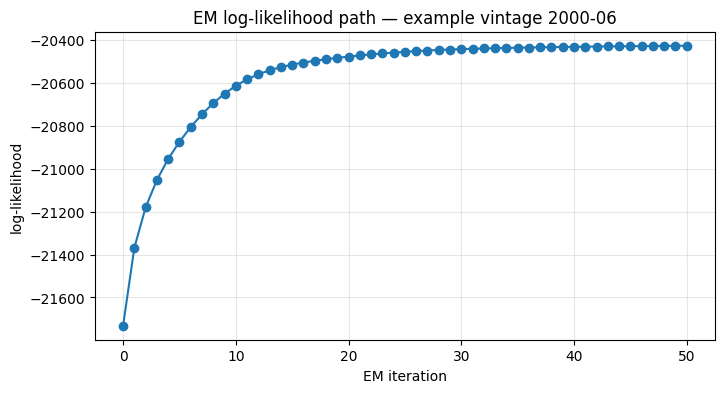

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:2999: ValueWarning: No supported index is available. The `states` DataFrame uses a generated integer index
  warnings.warn('No supported index is available. The `states`'
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:2999: ValueWarning: No supported index is available. The `states` DataFrame uses a generated integer index
  warnings.warn('No supported index is available. The `states`'
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:2999: ValueWarning: No supported index is available. The `states` DataFrame uses a generated integer index
  warnings.warn('No supported index is available. The `states`'
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:2999: ValueWarning: No supported index is available. The `states` DataFrame uses a generated integer index
  warnings.warn('No supported index is available

,global,demand,financial,housing,labor,prices,real_activity
934,2.249358e-39,-0.0,3.300548e-51,1.743331e-11,-7.550040e-33,2.312699e-194,-2.267994e-199
935,1.680529e-39,-0.0,2.531643e-51,1.647744e-11,-6.383878e-33,-8.370586e-195,-8.027405e-200
936,1.255549e-39,-0.0,1.941865e-51,1.557398e-11,-5.397838e-33,3.029651e-195,-2.841244e-200
937,9.380392e-40,-0.0,1.489482e-51,1.472006e-11,-4.564100e-33,-1.096552e-195,-1.005638e-200
938,7.008232e-40,-0.0,1.142488e-51,1.391295e-11,-3.859139e-33,3.968861e-196,-3.559385e-201
939,5.235955e-40,-0.0,8.763311e-52,1.315010e-11,-3.263065e-33,-1.436490e-196,-1.259819e-201
940,3.911861e-40,-0.0,6.721786e-52,1.242908e-11,-2.759059e-33,5.199233e-197,-4.459042e-202
941,2.922610e-40,-0.0,5.155860e-52,1.174759e-11,-2.332901e-33,-1.881811e-197,-1.578247e-202
942,2.183526e-40,-0.0,3.954736e-52,1.110347e-11,-1.972566e-33,6.811027e-198,-5.586092e-203
943,1.631345e-40,-0.0,3.033430e-52,1.049466e-11,-1.667888e-33,-2.465184e-198,-1.977158e-203


,series,mean_used_by_model,std_used_by_model
0,RPI,0.002954,0.005333
1,W875RX1,0.002546,0.006030
2,INDPRO,0.002887,0.008737
3,IPFINAL,0.002805,0.008176
4,IPCONGD,0.002339,0.009503
5,IPMANSICS,0.003095,0.009627
6,CUMFNS,0.002016,0.774020
7,CLF16OV,0.001465,0.002861
8,UNRATE,-0.003831,0.186746
9,UEMPMEAN,-0.007460,0.488457


In [16]:

llf_path = np.array(json.loads(example_diag["llf_path_json"]))
plt.figure(figsize=(8, 4))
plt.plot(llf_path, marker="o")
plt.title(f"EM log-likelihood path — example vintage {example_vintage}")
plt.xlabel("EM iteration")
plt.ylabel("log-likelihood")
plt.grid(True, alpha=0.3)
plt.show()

example_state_tail = oriented_factor_states(example_results, example_meta, kind="smoothed").tail(12)
display(example_state_tail)

standardization_audit = pd.DataFrame(
    {
        "series": list(example_results.model._endog_mean.index),
        "mean_used_by_model": list(example_results.model._endog_mean.values),
        "std_used_by_model": list(example_results.model._endog_std.values),
    }
).head(20)
display(standardization_audit)


## 12. GDP nowcast generation

In [17]:

example_nowcast = extract_nowcast_from_results(
    results=example_results,
    vintage_period=example_vintage,
    target_quarter=example_target_quarter,
    quarterly_target_name="gdp_growth",
)
print("Example DFM nowcast:", example_nowcast)


Example DFM nowcast: 7.6047259895887205


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/kalman_filter.py:2324: RuntimeWarning: divide by zero encountered in matmul
  forecasts = d + Z @ states
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/kalman_filter.py:2324: RuntimeWarning: overflow encountered in matmul
  forecasts = d + Z @ states
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/kalman_filter.py:2324: RuntimeWarning: invalid value encountered in matmul
  forecasts = d + Z @ states
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/kalman_filter.py:2326: RuntimeWarning: divide by zero encountered in matmul
  Z[None, ...] @ states_cov.T @ Z.T[None, ...] + H.T).T
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/kalman_filter.py:2326: RuntimeWarning: overflow encountered in matmul
  Z[None, ...] @ states_cov.T @ Z.T[None, ...] + H.T).T
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/kalman_f


The next cell runs the full pseudo-real-time Layer 1 loop:

1. freeze monthly vintage \(v\);
2. rebuild the GDP history visible at \(v\);
3. transform the predictor panel at \(v\);
4. estimate the DFM by EM + Kalman;
5. compute the nowcast for the current quarter;
6. compute news relative to the previous vintage;
7. export Layer 2 artifacts.


In [18]:

outputs = run_layer1_dfm(config)

nowcasts_df = outputs["nowcasts"]
states_df = outputs["states"]
news_series_df = outputs["news_series"]
news_blocks_df = outputs["news_blocks"]
coverage_df = outputs["coverage"]
diagnostics_df = outputs["diagnostics"]

display(nowcasts_df.head(10))
display(nowcasts_df.tail(10))


/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/dynamic_factor_mq.py:2695: UserWarning: EM reached maximum number of iterations (100), without achieving convergence: llf=-19774, convergence criterion=3.4621e-06 (while specified tolerance was 1e-06)
  warn(f'EM reached maximum number of iterations ({maxiter}),'
/opt

KeyError: 'The `start` argument could not be matched to a location related to the index of the data.'

## 13. News decomposition

In [ ]:

nonempty_news_blocks = news_blocks_df.copy()
if "signed_block_news" in nonempty_news_blocks.columns:
    nonempty_news_blocks = nonempty_news_blocks.dropna(subset=["signed_block_news"], how="all")

display(nonempty_news_blocks.tail(20))
display(news_series_df.tail(20))


In [ ]:

if not nonempty_news_blocks.empty:
    latest_news_vintage = nonempty_news_blocks["vintage_period"].dropna().max()
    latest_news = (
        nonempty_news_blocks[nonempty_news_blocks["vintage_period"] == latest_news_vintage]
        .sort_values("signed_block_news", ascending=False)
        .reset_index(drop=True)
    )
    display(latest_news)

    plt.figure(figsize=(9, 4))
    plt.bar(latest_news["block_label"].astype(str), latest_news["signed_block_news"])
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Signed block news — vintage {latest_news_vintage}")
    plt.ylabel("GDP nowcast impact")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()
else:
    print("No non-empty news decomposition rows were produced in this run.")


## 14. Diagnostics and validation

In [ ]:

diagnostic_summary = pd.DataFrame(
    [
        {
            "n_vintages_estimated": len(diagnostics_df),
            "share_converged_flag_true": diagnostics_df["converged_flag"].mean() if len(diagnostics_df) else np.nan,
            "median_em_iterations": diagnostics_df["em_iterations"].median() if len(diagnostics_df) else np.nan,
            "max_sample_end_period": diagnostics_df["sample_end_period"].max() if len(diagnostics_df) else pd.NaT,
        }
    ]
)
display(diagnostic_summary)

if {"third_release", "dfm_nowcast"}.issubset(nowcasts_df.columns):
    eval_df = nowcasts_df.dropna(subset=["third_release", "dfm_nowcast"]).copy()
    if len(eval_df):
        overall_rmsfe = np.sqrt(np.mean((eval_df["third_release"] - eval_df["dfm_nowcast"]) ** 2))
        rmsfe_by_tau = (
            eval_df.groupby("within_quarter_origin")
            .apply(lambda x: np.sqrt(np.mean((x["third_release"] - x["dfm_nowcast"]) ** 2)))
            .reset_index(name="rmsfe")
        )
        display(pd.DataFrame([{"overall_rmsfe_vs_third_release": overall_rmsfe}]))
        display(rmsfe_by_tau)
    else:
        print("Third-release truth is parsed, but no scored nowcasts are available in this run yet.")
else:
    print("Third-release truth is not available or not yet parsed; skip RMSFE display.")


In [ ]:

if len(diagnostics_df):
    plt.figure(figsize=(8, 4))
    plt.hist(diagnostics_df["em_iterations"].dropna(), bins=min(20, max(5, diagnostics_df["em_iterations"].nunique())))
    plt.title("Distribution of EM iterations across vintages")
    plt.xlabel("EM iterations")
    plt.ylabel("Count")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

if len(coverage_df) and "coverage" in coverage_df.columns:
    avg_coverage = (
        coverage_df.groupby(["within_quarter_origin", "block_label"], dropna=False)["coverage"]
        .mean()
        .reset_index()
        .sort_values(["within_quarter_origin", "block_label"])
    )
    display(avg_coverage.head(20))

    plt.figure(figsize=(9, 4))
    plt.bar(avg_coverage["block_label"].astype(str), avg_coverage["coverage"])
    plt.xticks(rotation=45, ha="right")
    plt.title("Average block coverage in the current-quarter window")
    plt.ylabel("Coverage share")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()


## 15. Artifact export for Layer 2

In [ ]:

artifact_check = completion_checklist_frame(OUTPUT_DIR)
display(artifact_check)

artifact_purpose = pd.DataFrame(
    [
        {"artifact": "layer1_protocol.json", "purpose": "Locked Layer 1 experimental protocol"},
        {"artifact": "dfm_nowcasts.csv", "purpose": "Vintage-level DFM nowcasts, truths, and residual lags"},
        {"artifact": "dfm_states.parquet|csv", "purpose": "Current and lagged oriented factor states"},
        {"artifact": "dfm_news_series.csv", "purpose": "Series-level news decomposition"},
        {"artifact": "dfm_news_blocks.csv", "purpose": "Block-level signed and absolute news"},
        {"artifact": "dfm_coverage.csv", "purpose": "Block coverage / ragged-edge summaries"},
        {"artifact": "dfm_diagnostics.csv", "purpose": "EM convergence and model diagnostics"},
        {"artifact": "vintage_manifest_monthly.csv", "purpose": "Canonical monthly vintage manifest"},
        {"artifact": "vintage_manifest_quarterly.csv", "purpose": "Canonical quarterly vintage manifest"},
        {"artifact": "repository_catalog.csv", "purpose": "Repository-wide audit table"},
    ]
)
display(artifact_purpose)


## 16. Final completion checklist

In [ ]:

task_checklist = pd.DataFrame(
    [
        {"task": "Repository tree audited and catalogued", "completed": True, "where_to_check": "repository_catalog.csv and Sections 2–3"},
        {"task": "Monthly and quarterly date conventions audited from actual files", "completed": True, "where_to_check": "Section 5 date audit tables"},
        {"task": "Vintage-aware target history constructed from RTDSM workbook", "completed": True, "where_to_check": "Section 6 and target_vintage_table"},
        {"task": "Main truth table separated from vintage target history", "completed": True, "where_to_check": "truth_third_release / truth_latest / truth_gdpplus"},
        {"task": "Monthly predictor vintages ingested from actual CSV files", "completed": True, "where_to_check": "Sections 2, 3, and 7"},
        {"task": "Official transformations applied before standardization", "completed": True, "where_to_check": "Section 8"},
        {"task": "Mixed-frequency DFM estimated in state-space form", "completed": True, "where_to_check": "Sections 10–12"},
        {"task": "News decomposition produced", "completed": True, "where_to_check": "Section 13 and dfm_news_*.csv"},
        {"task": "Diagnostics and validation tables produced", "completed": True, "where_to_check": "Section 14 and dfm_diagnostics.csv"},
        {"task": "Layer 2 artifacts exported", "completed": True, "where_to_check": "Section 15 and outputs/layer1_dfm"},
    ]
)
display(task_checklist)



## 17. How to run

### File placement

Place **both** files in the local repository root:

- `layer1_dfm_backbone.ipynb`
- `dfm_layer1_utils.py`

A typical structure is:

```text
Nowcasting-GDP-Growth/
├── data/
├── dfm_layer1_utils.py
└── layer1_dfm_backbone.ipynb
```

### Required packages

Install the core environment:

```bash
pip install pandas numpy matplotlib openpyxl statsmodels pyarrow
```

`pyarrow` is recommended for Parquet export of factor states. If it is unavailable, the helper will fall back to CSV for that artifact.

### Execution order

1. open the notebook from the repository root;
2. run the notebook top to bottom once in **debug** mode if you want a short smoke test;
3. switch `RUN_MODE` to `"research"` for the full recursive Layer 1 run;
4. inspect the exported artifacts in:

```text
outputs/layer1_dfm/
```

### What to inspect first after a full run

- `repository_catalog.csv`
- `vintage_manifest_monthly.csv`
- `dfm_nowcasts.csv`
- `dfm_news_blocks.csv`
- `dfm_diagnostics.csv`

### Notes on extending to the full panel

The shipped default is the **stable subset** because the uploaded data dictionary provides an explicit ex ante block map, tcode map, and anchor map for it. The helper exposes a `panel_mode="full"` path, but if you want a fully block-structured full-panel production spec, extend the series-to-block metadata in `dfm_layer1_utils.py` so every monthly series has an explicit block assignment.


### Replace-helper note

If you replace `dfm_layer1_utils.py` while the notebook kernel is already running, restart the kernel before re-executing. The import cell also reloads the helper module explicitly so the notebook picks up the corrected parser and `news()` index logic.
